# Compare pass2a (v3) vs pass2b (v5) GCD reconstructions

Both datasets contain the same 188 HESE data events, reconstructed with different GCDs.
- **v3**: pass2a GCDs
- **v5**: pass2b GCDs

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

In [3]:
import os

PLOT_DIR = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/unblind/pass2b_gcd/compare_pass2a_vs_pass2b"
os.makedirs(PLOT_DIR, exist_ok=True)

## Load datasets

In [4]:
SPLIT_DIR_TEMPLATE = (
    "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/datasets/"
    "flavor_globalfit/hese/split/data_HESE_pass2_{version}/"
    "mcd-simpletopology_flux-hese_feat-11features_plus_rloglmilli_econf_evtgen/"
    "bdt1_0.333333_bdt2_0.366667_length_10/"
    "dataset_data_HESE_pass2_{version}_{topology}.parquet"
)

COMBINED_PATH_TEMPLATE = (
    "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/datasets/"
    "flavor_globalfit/hese/combined/data_HESE_pass2_{version}/"
    "dataset_data_HESE_pass2_{version}.parquet"
)

def load_datasets(topology="total", version_a="v3", version_b="v5"):
    """Load DataFrames for two versions and a given topology (no intersection applied)."""
    if topology == "total":
        path_a = COMBINED_PATH_TEMPLATE.format(version=version_a)
        path_b = COMBINED_PATH_TEMPLATE.format(version=version_b)
    else:
        path_a = SPLIT_DIR_TEMPLATE.format(version=version_a, topology=topology)
        path_b = SPLIT_DIR_TEMPLATE.format(version=version_b, topology=topology)

    df_a = pd.read_parquet(path_a)
    df_b = pd.read_parquet(path_b)

    return df_a, df_b


# Quick sanity check
df_a_total, df_b_total = load_datasets(topology="total")
print(f"Total events pass2a: {len(df_a_total)}, pass2b: {len(df_b_total)}")
for topo in ["track", "cascade", "double"]:
    da, db = load_datasets(topology=topo)
    print(f"  {topo}: pass2a: {len(da)}, pass2b: {len(db)} events")

Total events pass2a: 188, pass2b: 188
  track: pass2a: 64, pass2b: 62 events
  cascade: pass2a: 122, pass2b: 124 events
  double: pass2a: 2, pass2b: 2 events


## Comparison function

In [5]:
def compare_variable(
    variable,
    topology="total",
    reco_energy_threshold=None,
    version_a="v3",
    version_b="v5",
    label_a="pass2a (v3)",
    label_b="pass2b (v5)",
    bins=30,
    log_x=False,
):
    """
    Compare a variable between two reconstruction versions.

    Parameters
    ----------
    variable : str
        Column name to compare.
    topology : str
        One of 'total', 'track', 'cascade', 'double'.
    reco_energy_threshold : float or None
        Minimum reco_energy (GeV) to include, applied independently per dataset.
    version_a, version_b : str
        Dataset version strings (e.g. 'v3', 'v5').
    label_a, label_b : str
        Legend labels for each version.
    bins : int
        Number of histogram bins.
    log_x : bool
        Use log-spaced bins and log x-axis for the left panel.
    """
    df_a, df_b = load_datasets(topology=topology, version_a=version_a, version_b=version_b)

    # Apply reco_energy threshold independently to each dataset
    if reco_energy_threshold is not None:
        df_a = df_a[df_a["reco_energy"] >= reco_energy_threshold]
        df_b = df_b[df_b["reco_energy"] >= reco_energy_threshold]

    vals_a = df_a[variable].values
    vals_b = df_b[variable].values
    n_a = len(vals_a)
    n_b = len(vals_b)

    # Event-by-event difference: only events present in both files and passing both cuts
    shared_idx = df_a.index.intersection(df_b.index)
    diff = df_b.loc[shared_idx, variable].values - df_a.loc[shared_idx, variable].values

    title_suffix = f"topology={topology}, N({label_a})={n_a}, N({label_b})={n_b}"
    if reco_energy_threshold is not None:
        title_suffix += f", E_reco >= {reco_energy_threshold:.0f} GeV"

    # Bin edges span the full range of both datasets.
    # The upper edge is nudged above finite.max() so that the maximum-valued event
    # is strictly inside the last bin and not silently dropped by np.histogram.
    combined = np.concatenate([vals_a, vals_b])
    finite = combined[np.isfinite(combined)]
    vmin, vmax = finite.min(), finite.max()
    if log_x and np.all(finite > 0):
        bin_edges = np.logspace(np.log10(vmin), np.log10(vmax * (1 + 1e-9)), bins + 1)
    else:
        bin_edges = np.linspace(vmin, vmax + 1e-9 * abs(vmax), bins + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f"{variable} — {title_suffix}", fontsize=13)

    # Left: overlapping histograms
    ax = axes[0]
    ax.hist(vals_a, bins=bin_edges, histtype="step", label=label_a, linewidth=1.5)
    ax.hist(vals_b, bins=bin_edges, histtype="step", label=label_b, linewidth=1.5, linestyle="--")
    ax.set_xlabel(variable)
    ax.set_ylabel("Events")
    ax.set_title("Distributions")
    ax.legend()
    if log_x:
        ax.set_xscale("log")
        ax.set_xlim(bin_edges[0] / 1.1, bin_edges[-1] * 1.1)
    else:
        margin = 0.05 * (bin_edges[-1] - bin_edges[0])
        ax.set_xlim(bin_edges[0] - margin, bin_edges[-1] + margin)

    # Right: event-by-event difference (shared events only)
    ax = axes[1]
    finite_diff = diff[np.isfinite(diff)]
    diff_max = finite_diff.max()
    diff_bins = np.linspace(finite_diff.min(), diff_max + 1e-9 * abs(diff_max), bins + 1)
    ax.hist(finite_diff, bins=diff_bins, histtype="stepfilled", alpha=0.7, color="steelblue")
    ax.axvline(0, color="black", linewidth=1, linestyle="--")
    ax.axvline(np.median(finite_diff), color="red", linewidth=1.2, linestyle=":",
               label=f"median = {np.median(finite_diff):.3g}")
    ax.set_xlabel(f"{variable}: {label_b} − {label_a}")
    ax.set_ylabel("Events")
    ax.set_title(f"Event-by-event difference (N={len(shared_idx)})")
    ax.legend()
    diff_margin = 0.05 * (diff_bins[-1] - diff_bins[0])
    ax.set_xlim(diff_bins[0] - diff_margin, diff_bins[-1] + diff_margin)

    plt.tight_layout()

    fname = f"{variable}_{topology}"
    if reco_energy_threshold is not None:
        fname += f"_Emin{reco_energy_threshold:.0f}GeV"
    fig.savefig(os.path.join(PLOT_DIR, fname + ".pdf"), bbox_inches="tight")

    plt.show()

    # Print summary statistics
    rel_diff = diff / df_a.loc[shared_idx, variable].values
    print(f"  mean diff : {np.nanmean(diff):.4g}")
    print(f"  median diff : {np.nanmedian(diff):.4g}")
    print(f"  std diff : {np.nanstd(diff):.4g}")
    print(f"  mean rel diff: {np.nanmean(rel_diff)*100:.3g} %")
    print(f"  median rel diff: {np.nanmedian(rel_diff)*100:.3g} %")

## reco_energy comparison

### Total sample

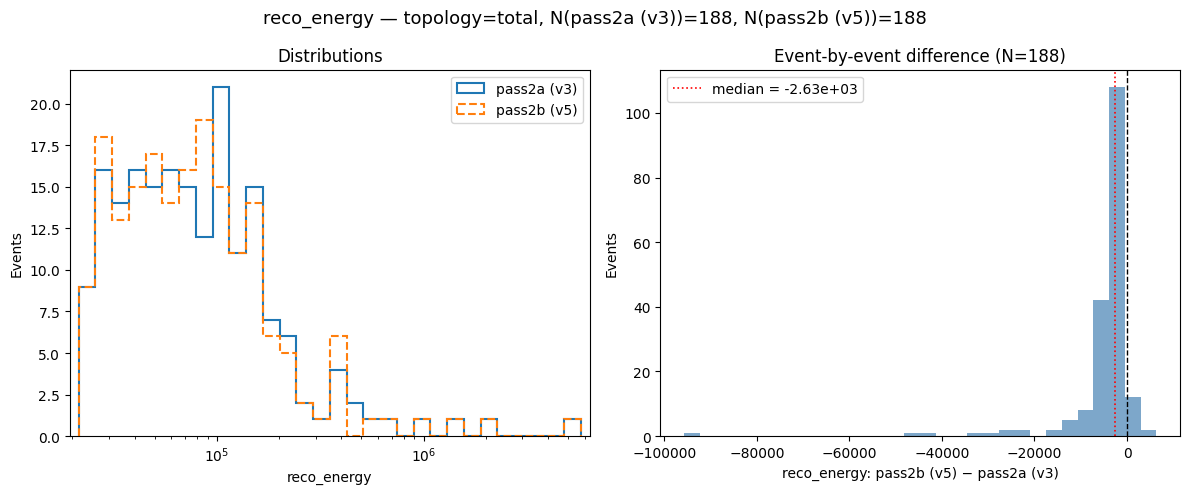

  mean diff : -4938
  median diff : -2630
  std diff : 9331
  mean rel diff: -3.65 %
  median rel diff: -3.59 %


: 

: 

In [ ]:
compare_variable("reco_energy", topology="total", log_x=True)

### Total sample — reco_energy >= 60 TeV

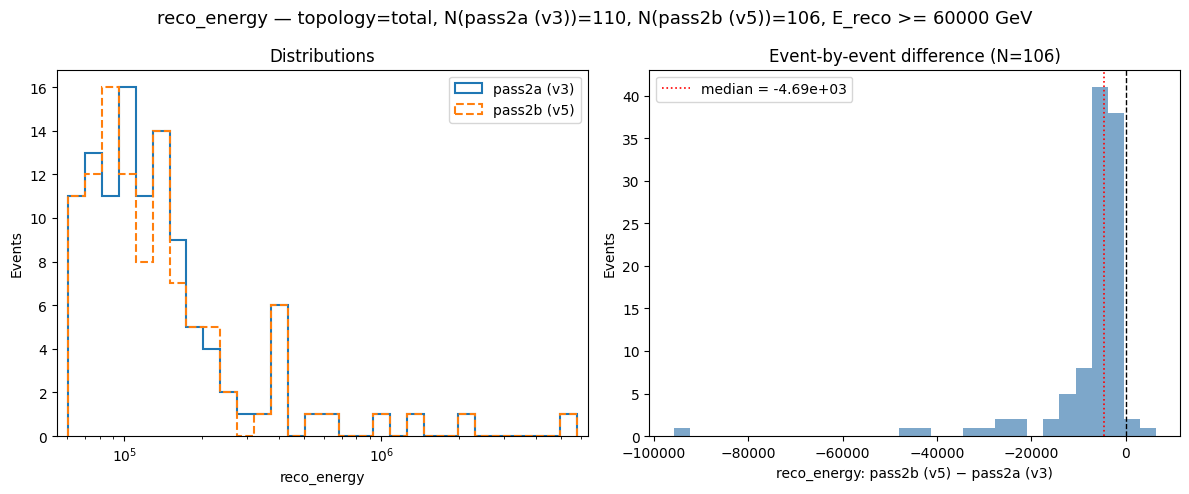

  mean diff : -7710
  median diff : -4687
  std diff : 1.165e+04
  mean rel diff: -3.89 %
  median rel diff: -3.62 %


: 

: 

In [ ]:
compare_variable("reco_energy", topology="total", reco_energy_threshold=60e3, log_x=True)

### Tracks

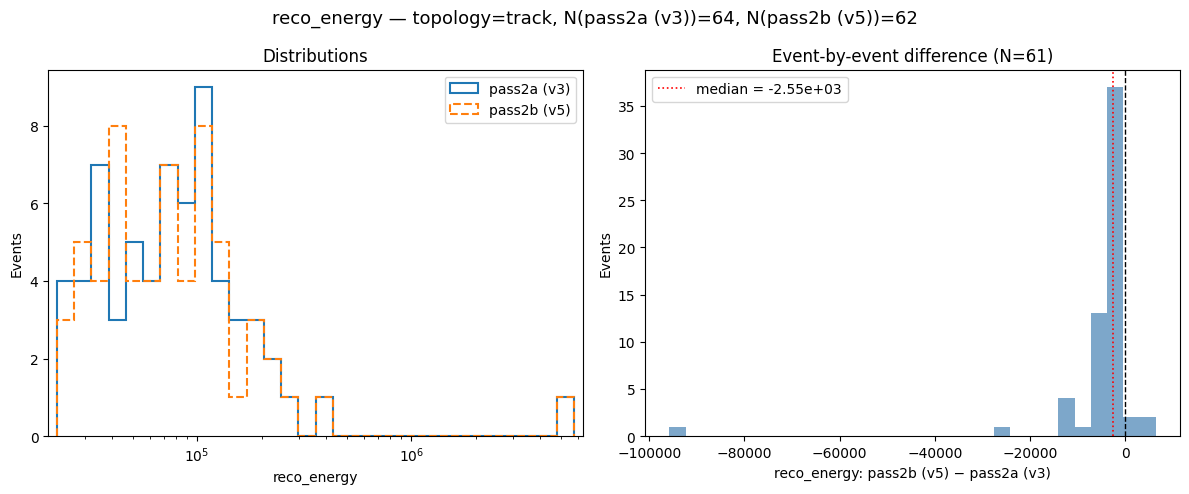

  mean diff : -5053
  median diff : -2547
  std diff : 1.252e+04
  mean rel diff: -3.63 %
  median rel diff: -3.4 %


: 

: 

In [ ]:
compare_variable("reco_energy", topology="track", log_x=True)

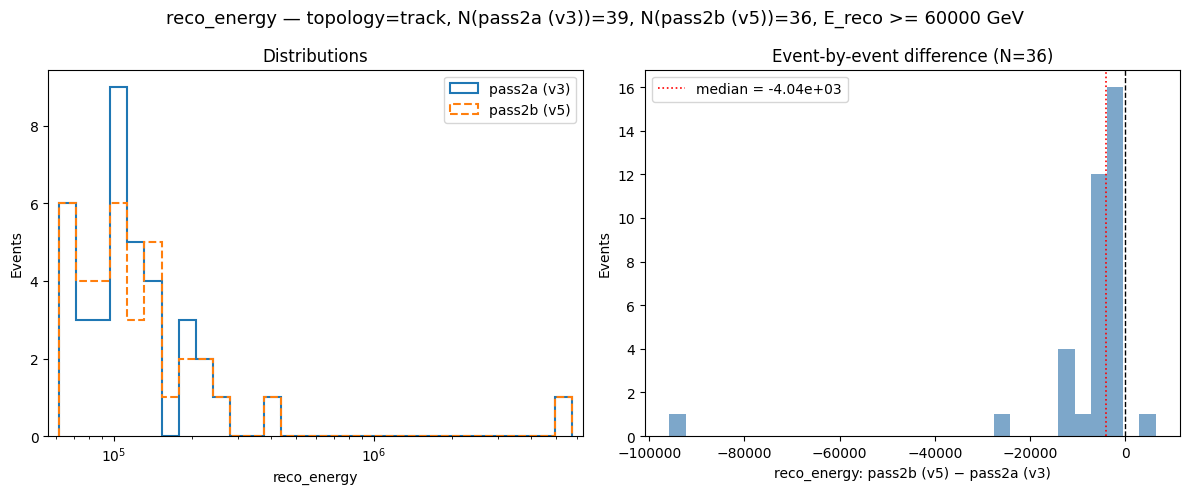

  mean diff : -7728
  median diff : -4037
  std diff : 1.568e+04
  mean rel diff: -4.01 %
  median rel diff: -3.43 %


: 

: 

In [ ]:
compare_variable("reco_energy", topology="track", reco_energy_threshold=60e3,log_x=True)

### Cascades

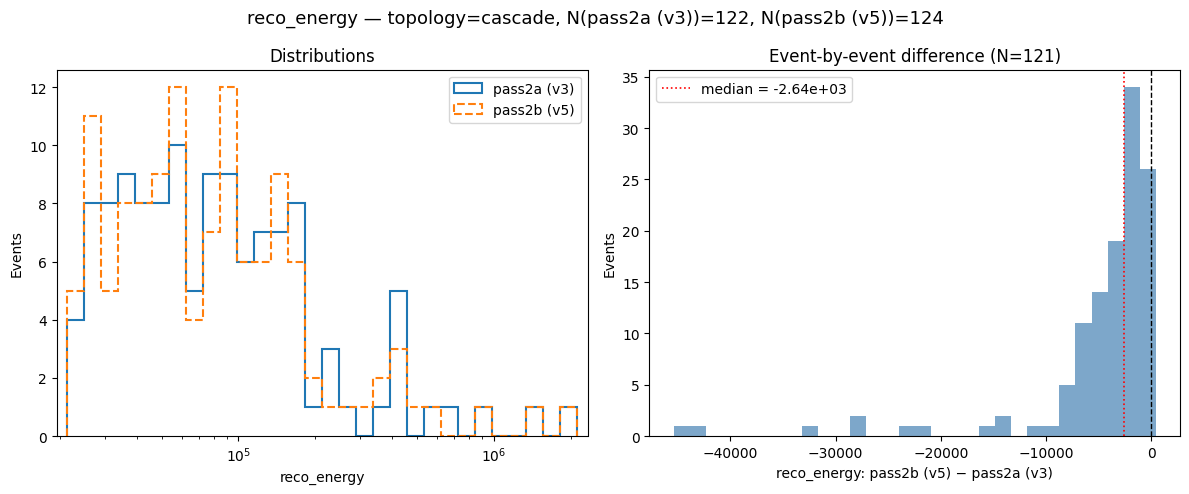

  mean diff : -4993
  median diff : -2635
  std diff : 7462
  mean rel diff: -3.64 %
  median rel diff: -3.61 %


: 

: 

In [ ]:
compare_variable("reco_energy", topology="cascade", log_x=True)

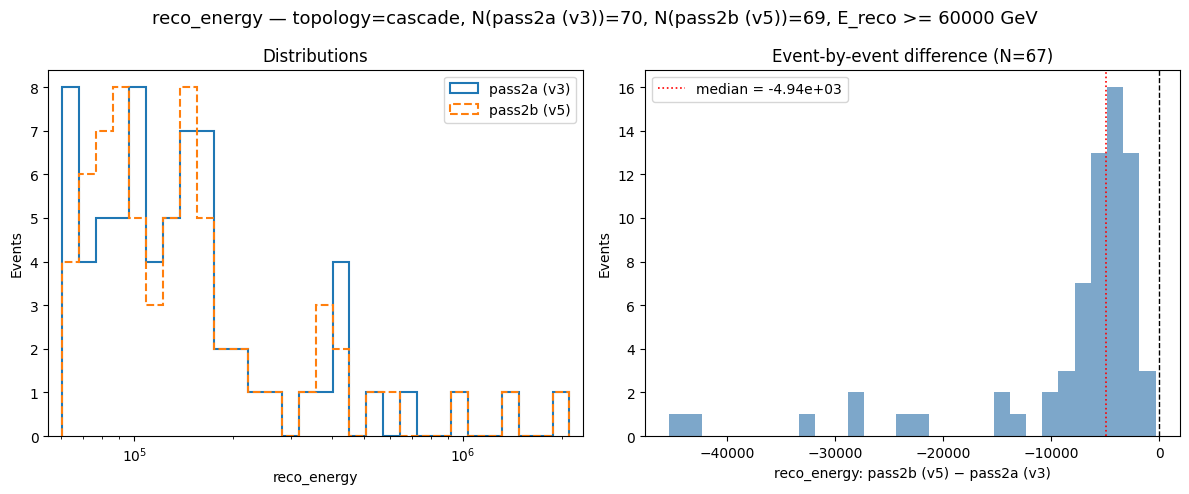

  mean diff : -7903
  median diff : -4940
  std diff : 8998
  mean rel diff: -3.87 %
  median rel diff: -3.68 %


: 

: 

In [ ]:
compare_variable("reco_energy", topology="cascade", reco_energy_threshold=60e3,log_x=True)

### Doubles

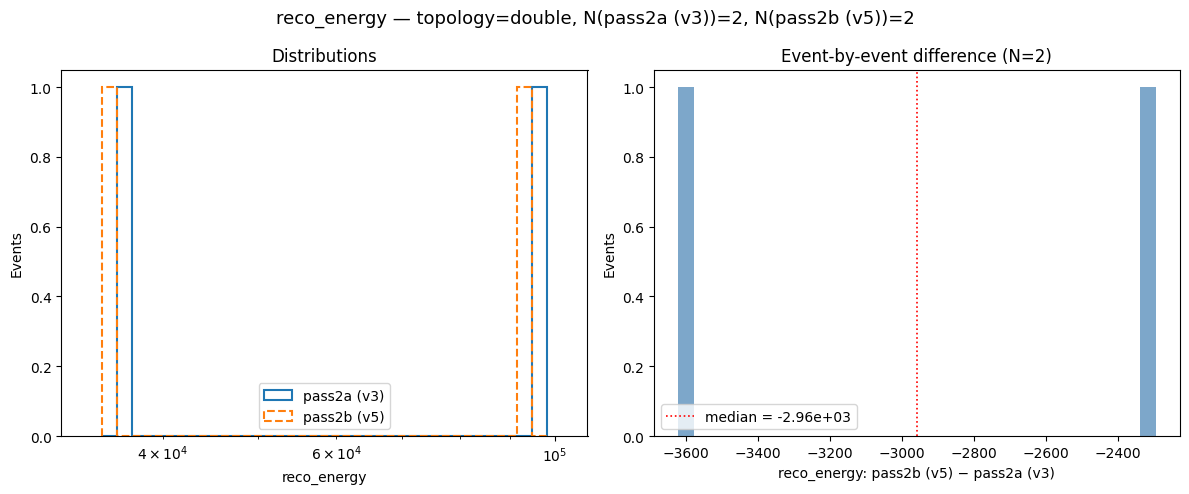

  mean diff : -2958
  median diff : -2958
  std diff : 664.8
  mean rel diff: -4.95 %
  median rel diff: -4.95 %


: 

: 

In [ ]:
compare_variable("reco_energy", topology="double", log_x=True)

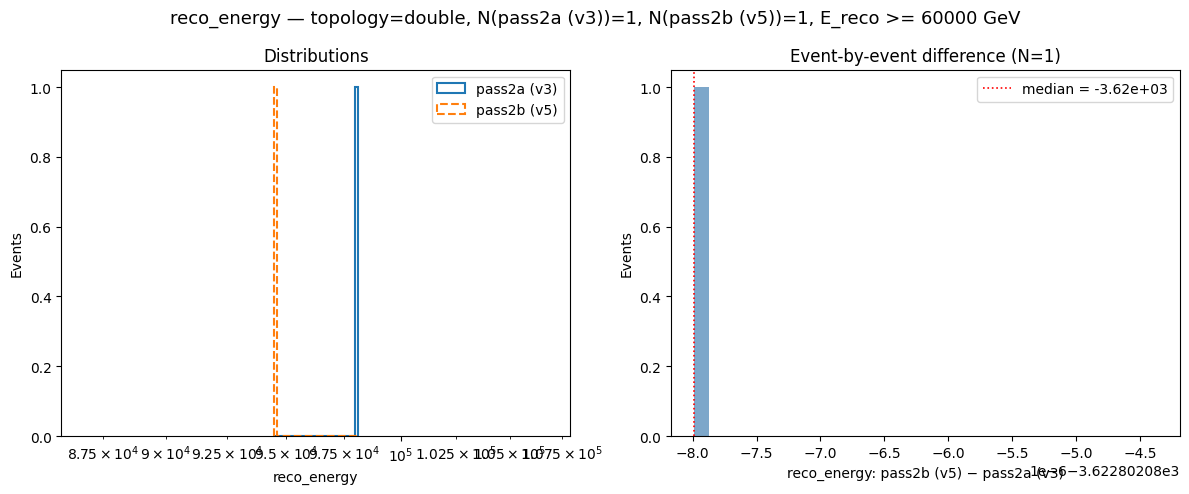

  mean diff : -3623
  median diff : -3623
  std diff : 0
  mean rel diff: -3.69 %
  median rel diff: -3.69 %


: 

: 

In [ ]:
compare_variable("reco_energy", topology="double", reco_energy_threshold=60e3,log_x=True)

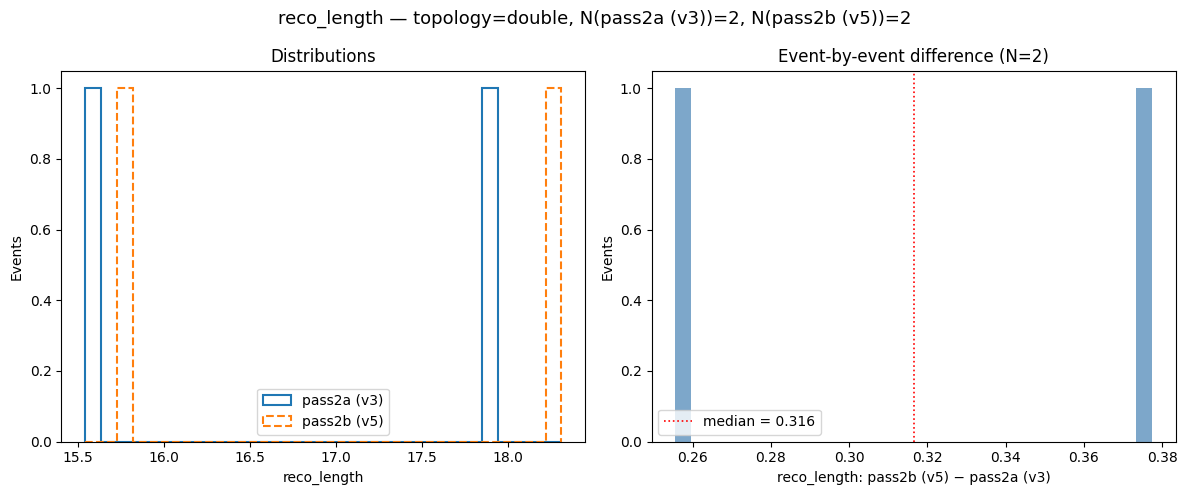

  mean diff : 0.3165
  median diff : 0.3165
  std diff : 0.06089
  mean rel diff: 1.87 %
  median rel diff: 1.87 %


: 

In [ ]:
compare_variable("reco_length", topology="double", log_x=False)

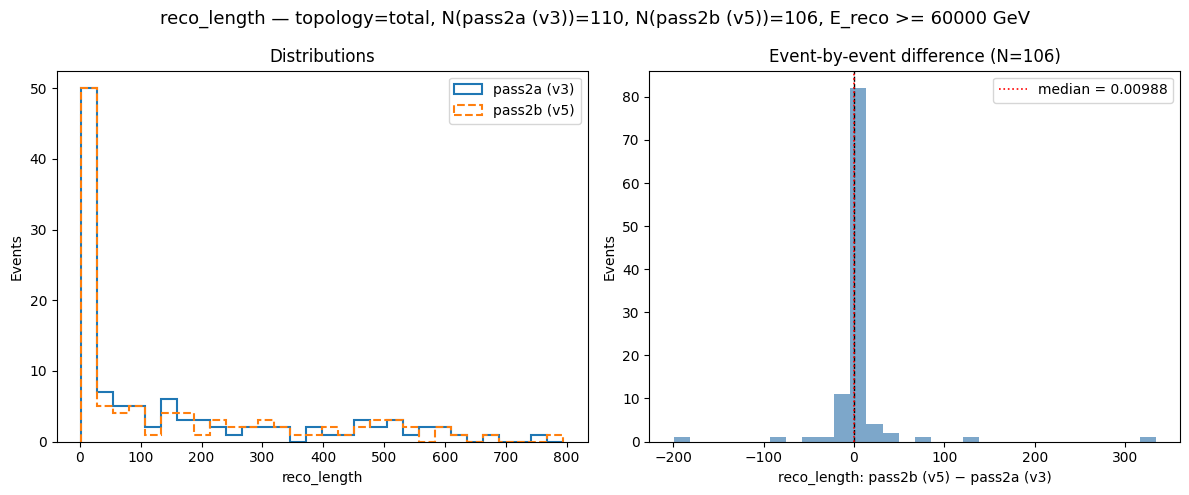

  mean diff : 2.56
  median diff : 0.00988
  std diff : 42.79
  mean rel diff: 8.1 %
  median rel diff: 0.0256 %


: 

In [ ]:
compare_variable("reco_length", topology="total", log_x=False, reco_energy_threshold=60e3)

## Topology migration: pass2a → pass2b

Which events changed classification (track / cascade / double) between the two GCD versions?

In [6]:
TOPOLOGIES = ["track", "cascade", "double"]

def build_topology_map(version):
    """Return a Series mapping event index -> topology for a given version."""
    parts = []
    for topo in TOPOLOGIES:
        df = pd.read_parquet(SPLIT_DIR_TEMPLATE.format(version=version, topology=topo))
        s = pd.Series(topo, index=df.index, name="topology")
        parts.append(s)
    return pd.concat(parts)

topo_v3 = build_topology_map("v3")
topo_v5 = build_topology_map("v5")

migration = pd.DataFrame({"pass2a": topo_v3, "pass2b": topo_v5})

# Migration table (confusion matrix)
table = pd.crosstab(
    migration["pass2a"], migration["pass2b"],
    rownames=["pass2a (v3)"], colnames=["pass2b (v5)"],
    margins=True, margins_name="Total",
)
print("=== Topology migration table ===")
print(table.to_string())

# Events that changed topology
changed = migration[migration["pass2a"] != migration["pass2b"]].copy()

# Add reco_energy from both versions for context
combined_v3 = pd.read_parquet(COMBINED_PATH_TEMPLATE.format(version="v3"))["reco_energy"]
combined_v5 = pd.read_parquet(COMBINED_PATH_TEMPLATE.format(version="v5"))["reco_energy"]
changed["reco_energy_v3 [GeV]"] = combined_v3.loc[changed.index]
changed["reco_energy_v5 [GeV]"] = combined_v5.loc[changed.index]
changed["transition"] = changed["pass2a"] + " → " + changed["pass2b"]

print(f"\n=== {len(changed)} event(s) changed topology ===")
display_cols = ["transition", "reco_energy_v3 [GeV]", "reco_energy_v5 [GeV]"]
print(changed[display_cols].sort_values("transition").to_string(float_format="{:.1f}".format))

=== Topology migration table ===
pass2b (v5)  cascade  double  track  Total
pass2a (v3)                               
cascade          121       0      1    122
double             0       2      0      2
track              3       0     61     64
Total            124       2     62    188

=== 4 event(s) changed topology ===
                        transition  reco_energy_v3 [GeV]  reco_energy_v5 [GeV]
126865 46801086 0  cascade → track               48089.8               44535.1
119470 48424887 0  track → cascade               93528.1               94778.4
130219 10092093 0  track → cascade               25055.9               24416.9
137845 43811235 0  track → cascade               98998.3               91879.7


## Double cascade above 60 TeV

Detailed comparison of the one double cascade event with reco_energy > 60 TeV.

In [7]:
COLS = ["reco_energy", "reco_length", "reco_dir", "eratio", "bdt_scores1", "bdt_scores2"]
RENAME = {"reco_dir": "reco_zenith"}

df_a_double, df_b_double = load_datasets(topology="double")

high_e_idx = df_a_double[df_a_double["reco_energy"] > 60e3].index

rows = []
for version_label, df in [("pass2a (v3)", df_a_double), ("pass2b (v5)", df_b_double)]:
    shared = high_e_idx.intersection(df.index)
    if len(shared) == 0:
        print(f"No event above 60 TeV in {version_label}")
        continue
    row = df.loc[shared, COLS].rename(columns=RENAME).copy()
    row.insert(0, "version", version_label)
    rows.append(row)

table = pd.concat(rows).set_index("version")
display(table)

,reco_energy,reco_length,reco_zenith,eratio,bdt_scores1,bdt_scores2
version,,,,,,
pass2a (v3),98091.747134,17.931135,1.106503,-0.857824,0.997102,0.991212
pass2b (v5),94468.945046,18.308508,1.120556,-0.861648,0.997340,0.990745
